## Tutorial 2 - Boundary Conditions and 2D/3D Simulations

This tutorial will cover boundary conditions, and will also setup basic 2D and 3D simulations

In [60]:
from Medium import Medium, Atom
from BoundaryConditions import BoundaryConditions
from Beam import Beam
import Simulation as sim

#### **BOUNDARY CONDITIONS**
To start any simulation, we need to define boundary conditions using the 'BoundaryConditions' class. The non-GMSH version supports 3 types of BC's:
1) Fixed Temperature
2) Blackbody Radiation
3) None (Insulated)
More boundary conditions are implemented for the Gmsh version of the class, which is covered in the next tutorial.

**NOTE**: The ordering of faces is [Top, Bottom, Left, Right] for 2D and [Top, Bottom, Left, Right, Front, Back] for 3D

#####  **None**
No variables need to be defined for this boundary condition since it represents perfect insulation. 

In [61]:
from BoundaryConditions import BoundaryConditions
BCs = BoundaryConditions(types = ['None', 'None', 'None', 'None'])

#####  **Fixed Temperature**
You can either define one temperature for all fixed boundaries, or one temperature for each fixed boundary. \
Ensure in the latter case that the number of fixed boundaries is equal to the number of fixed temperatures

In [62]:
T_fixed = [400.0, 200.0] # [K]
BCs = BoundaryConditions(types = ['Fixed', 'None', 'Fixed', 'None'], T0 = T_fixed)

#####  **Blackbody Radiation**
This represents heat radiating away to the surrounding enviornment.\
**NOTE**: This software assumes that the surrounding environment is large enough that any heating caused by the radiation is negligble. 

Two values need to be defined:
1) The emissivity (between 0 - 1)
2) The ambient temperature (surrounding temperature)

Similar to fixed boundaries, different emissivities can be provided for each face. \
However, only one ambient temperature is allowed.

In [63]:
epsilons = [0.9, 0.8] 
T_ambient = 298
BCs = BoundaryConditions(types = ['None', 'BBR', 'None', 'BBR'], eps = epsilons, T_amb = T_ambient)

Similar to the fixed boundary conditions, you can either supply one emissivity for the entire medium, or one for each boundary.
    

#### **2D SIMULATION**
Now we have everything necessary to begin simulations. Let's start by redefining our beam and aluminum medium from the last tutorial.\
**NOTE**: Lz still needs to be provided for 2D simulations since the beam is spread out over a 2D area in the YZ plane. 

In [64]:
I = 0.5e-6/1.602e-19 # s^-1
E = 5e6 # eV
Z = 1 # Atomic number 
dimension = 2 # Beam can be 2D or 3D
L = 1e-6 # Meters
beam = Beam(E, I, Z, dimension, L = L)

name = 'Al'
atomic_fraction = 1 # percentange (out of 1)
Z_Al = 13
A_Al = 27 # Given in g/mol
Al_atom = Atom(name, atomic_fraction, Z_Al, A_Al)

SRIM_fileName = "Al//Hydrogen in Aluminum.txt" # relative path or absolute path
rho_Al = 2700 # Density in kg/m^3
C_Al = 900 # Specific heat capacity in J/(kg*K)
k_Al = 205.0 # Heat conductivity in W/(m*K)
Lx_Al = 10e-6 # [m]
Ly_Al = 3e-6
Lz_Al = 1e-6
x0_Al = 0 

aluminum = Medium(rho_Al, C_Al, k_Al, Al_atom, SRIM_fileName,
                  Lx = Lx_Al, Ly = Ly_Al, Lz = Lz_Al, 
                  x0 = x0_Al, name = 'Aluminum') 

Next, we will define some boundary conditions.

In [65]:
epsilons = [0.3, 0.99]
T_fixed = 200
T_ambient = 298
BC = BoundaryConditions(['Fixed', 'BBR', 'None', 'BBR'], T0 = T_fixed, T_amb = T_ambient, eps = epsilons)

Now we will define some settings for the simulation. The simulation functions themselves have loads of customizability so here we will only showcase some of them:
+ T0 -> initial temperature of object (aside from any boundary conditions)
+ dx, dy -> controls the mesh resolution in x and y directions
+ dt -> controls the time step
+ dt_ramp -> controls how quickly the time step ramps
+ dT_target -> maximum allowed temperature between time steps
+ x_units -> scales the x-axis corresponding to a unit (i.e. x_units = 'mm' scales to milimeters)

More options can be found in the 'Simulation' package.

In [66]:
dx = 0.5e-6
dy = 0.01e-6
dT = 100
dt_ramp = 1.5
units = 'um'

The simulation will run and plot the temperature distribution over time. \
After it is finished running it will return two 1D arrays: Time [s], and Max Temperature [K]\
**NOTE**: debug = True can also be enabled for troubleshooting + additional plotting

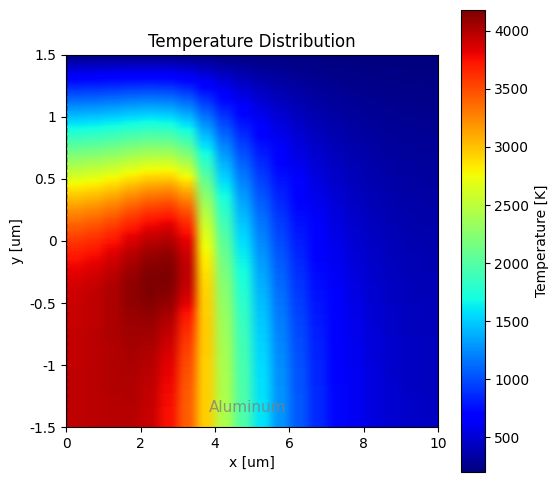

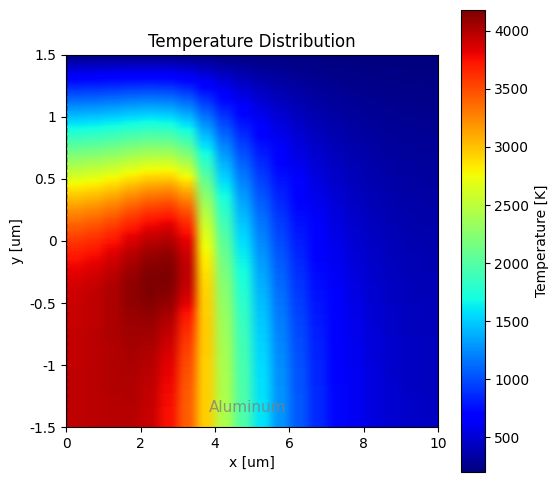

In [67]:
time = 5
dt_initial = 1e-5
ts, Ts = sim.heateq_solid_2d(beam, aluminum, BC, Ly_Al, time, dt = dt_initial,
                             dx=dx, dy=dy, view=True, 
                             dt_ramp= dt_ramp, dT_target = dT, 
                             x_units=units, y_units = units, 
                             view=True, debug = False)

**NOTE**: if the above simulation takes too long to run, try to decrease the mesh resolution. 

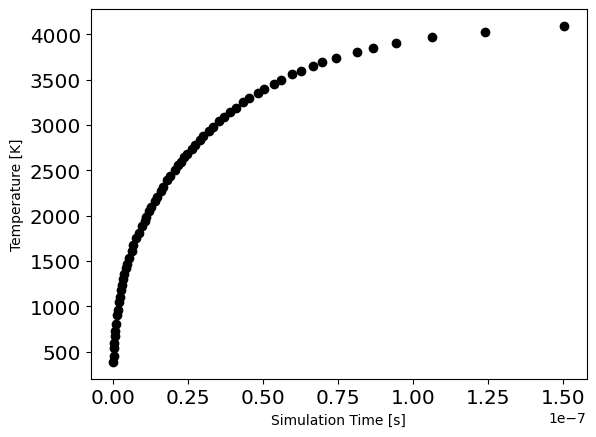

In [77]:
import matplotlib.pyplot as plt
plt.plot(ts[:65], Ts[:65], 'ko')
plt.ylabel("Temperature [K]")
plt.xlabel("Simulation Time [s]")
plt.tick_params(labelsize='x-large')
plt.show()

#### **3D SIMULATION**
Nothing really changes for 3D simulation, except now we have 6 boundary conditions and an extra dimension. \
Simulations in 3D also generally take much longer.\
**NOTE**: mayavi needs to be installed for the viewer to work, which is a pain in the ass. Read the 'README.md' for more info.

In [68]:
I = 0.5e-6/1.602e-19 # s^-1
E = 5e6 # eV
Z = 1 # Atomic number 
dimension = 3 # Beam can be 2D or 3D
L = 1e-6 # Meters
W = 0.5e-6
beam = Beam(E, I, Z, dimension, L = L, W = W)

name = 'Al'
atomic_fraction = 1 # percentange (out of 1)
Z_Al = 13
A_Al = 27 # Given in g/mol
Al_atom = Atom(name, atomic_fraction, Z_Al, A_Al)

SRIM_fileName = "Al//Hydrogen in Aluminum.txt" # relative path or absolute path
rho_Al = 2700 # Density in kg/m^3
C_Al = 900 # Specific heat capacity in J/(kg*K)
k_Al = 205.0 # Heat conductivity in W/(m*K)
Lx_Al = 10e-6 # [m]
Ly_Al = 3e-6
Lz_Al = 2e-6
x0_Al = 0 

aluminum = Medium(rho_Al, C_Al, k_Al, Al_atom, SRIM_fileName,
                  Lx = Lx_Al, Ly = Ly_Al, Lz = Lz_Al, x0 = x0_Al, name = 'Aluminum') 

Define boundary conditions

In [69]:
epsilons = [0.3, 0.99]
T_fixed = 200
T_ambient = 298
BC = BoundaryConditions(['Fixed', 'Fixed', 'BBR', 'BBR', 'None', 'None'], T0 = T_fixed, T_amb = T_ambient, eps = epsilons)

Define simulation settings

In [70]:
dx = 0.5e-6
dy = 0.05e-6
dz = 0.05e-6
dT = 100
dt_ramp = 1.5
units = 'um'

Run simulation (decrease resolution if it takes forever)

In [71]:
time = 5
dt_initial = 1e-5
ts, Ts = sim.heateq_solid_3d(beam, aluminum, BC, Ly_Al, Lz_Al, time, 
                             dt = dt_initial, dt_ramp= dt_ramp, dT_target = dT, 
                             dx=dx, dy=dy, dz=dz,
                             x_units=units, y_units = units, z_units = units
                             view=True, debug = False)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3806801025.py, line 6)